# 0. Check Dataset

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_359460/2405917951.py:10: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, skiprows=1, sep='\s+', names=column_names, engine='python')


--- File: 090_Tm_9.5_HS_3.5.out ---
   t(s)         x1(m)         x2(m)       x3(rad)       x4(m/s)       x5(m/s)  \
0   0.1  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
1   0.2  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
2   0.3 -5.692539e-10 -1.279603e-09 -1.657641e-08 -1.622922e-09 -5.026911e-11   
3   0.4 -2.062058e-09 -1.279068e-09 -8.653565e-08 -4.142708e-09  2.449873e-09   
4   0.5 -3.985028e-09  9.613750e-09 -2.684763e-07 -1.317172e-09  1.496388e-08   

      x6(rad/s)  
0  0.000000e+00  
1  0.000000e+00  
2 -7.565340e-09  
3 -3.864943e-08  
4 -1.178788e-07  


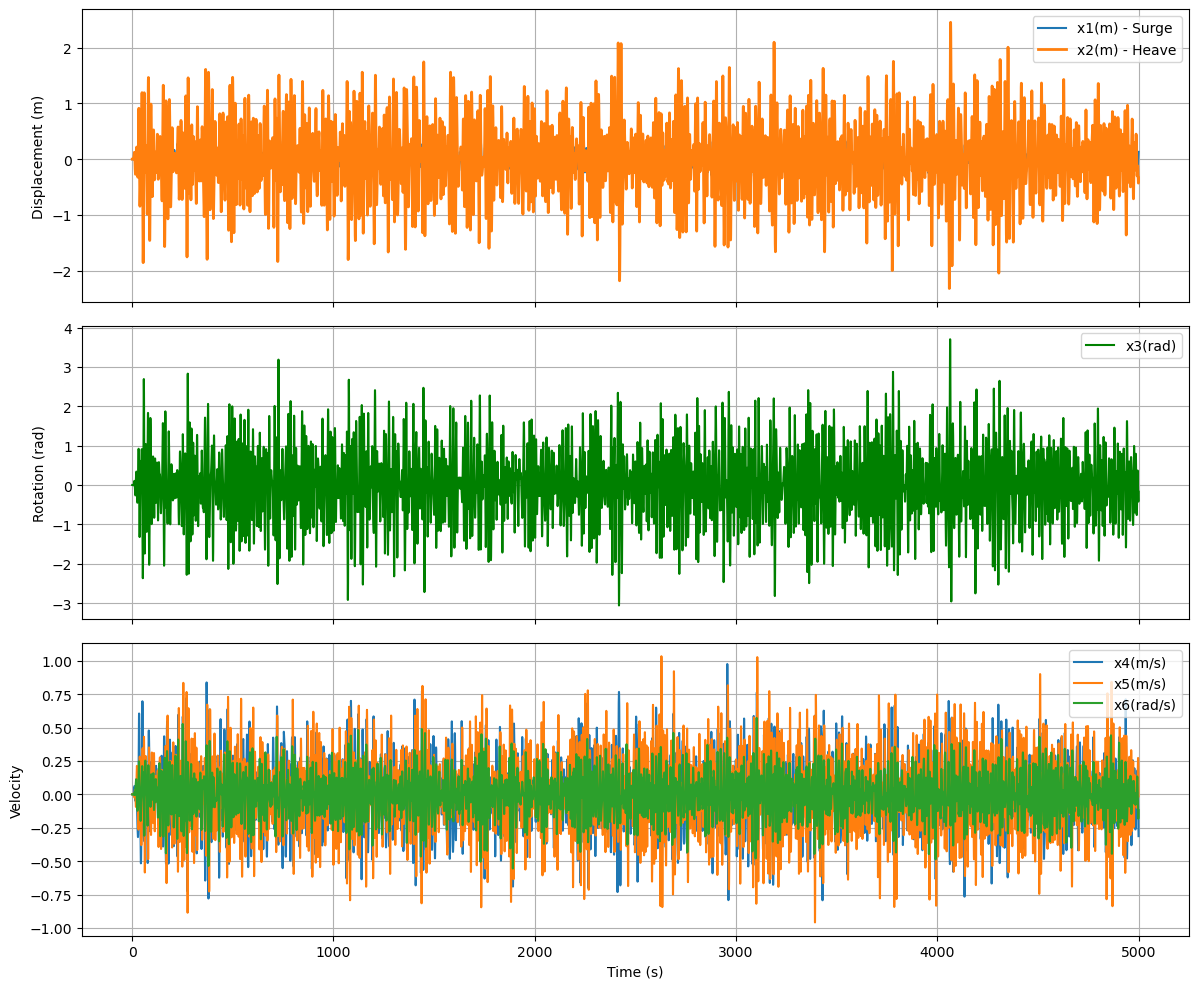

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. 파일 로딩 함수 (방금 제공된 코드의 핵심 로직 추출)
def test_load_single_file(file_path):
    column_names = ['t(s)', 'x1(m)', 'x2(m)', 'x3(rad)', 'x4(m/s)', 'x5(m/s)', 'x6(rad/s)']
    try:
        # 헤더 1줄 스킵, 공백 구분자 사용
        df = pd.read_csv(file_path, skiprows=1, sep='\s+', names=column_names, engine='python')
        return df
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

# 2. 경로 설정 (실제 파일명 하나를 지정하세요)
data_dir = "dataset_grid"
sample_file = "090_Tm_9.5_HS_3.5.out"  # 확인하고 싶은 파일명으로 변경
path = os.path.join(data_dir, sample_file)

# 3. 실행 및 시각화
df = test_load_single_file(path)

if df is not None:
    print(f"--- File: {sample_file} ---")
    print(df.head()) # 데이터 상단 출력
    
    # 그래프 그리기
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # (1) x1, x2 (Surge, Heave)
    axes[0].plot(df['t(s)'], df['x1(m)'], label='x1(m) - Surge')
    axes[0].plot(df['t(s)'], df['x2(m)'], label='x2(m) - Heave', linewidth=2)
    axes[0].set_ylabel('Displacement (m)')
    axes[0].legend()
    axes[0].grid(True)
    
    # (2) x3 (Pitch/Yaw 등 각도 데이터)
    axes[1].plot(df['t(s)'], df['x3(rad)'], color='green', label='x3(rad)')
    axes[1].set_ylabel('Rotation (rad)')
    axes[1].legend()
    axes[1].grid(True)
    
    # (3) x4, x5, x6 (속도 데이터)
    axes[2].plot(df['t(s)'], df['x4(m/s)'], label='x4(m/s)')
    axes[2].plot(df['t(s)'], df['x5(m/s)'], label='x5(m/s)')
    axes[2].plot(df['t(s)'], df['x6(rad/s)'], label='x6(rad/s)')
    axes[2].set_ylabel('Velocity')
    axes[2].set_xlabel('Time (s)')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("파일을 불러오지 못했습니다. 경로와 파일명을 다시 확인하세요.")

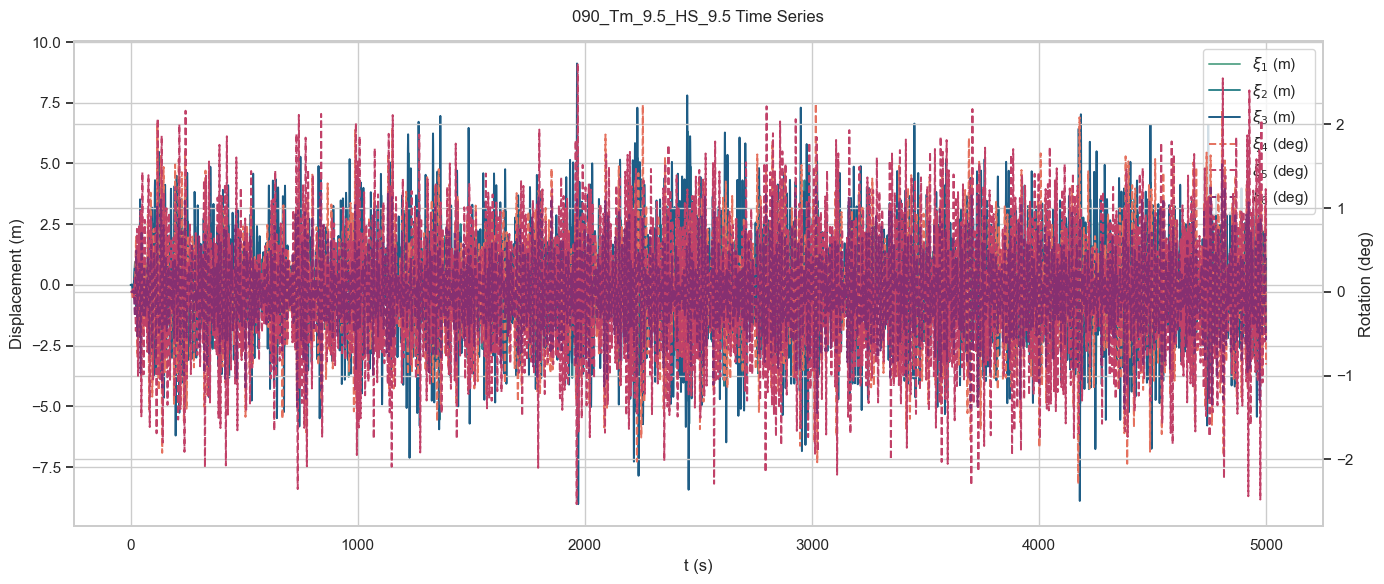

In [1]:
# Paste this whole cell into a Jupyter notebook code cell and run it.

from pathlib import Path
import html
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")

# OrcaFlex-style labels often use tags such as <greek>x</greek><sub>2</sub>.
# Convert them to matplotlib mathtext so Greek letters/subscripts render correctly.
GREEK_MATH_MAP = {
    "a": r"\alpha", "b": r"\beta", "c": r"\chi", "d": r"\delta",
    "e": r"\epsilon", "f": r"\phi", "g": r"\gamma", "h": r"\eta",
    "i": r"\iota", "j": r"\varphi", "k": r"\kappa", "l": r"\lambda",
    "m": r"\mu", "n": r"\nu", "o": r"o", "p": r"\pi",
    "q": r"\theta", "r": r"\rho", "s": r"\sigma", "t": r"\tau",
    "u": r"\upsilon", "v": r"\varpi", "w": r"\omega", "x": r"\xi",
    "y": r"\psi", "z": r"\zeta",
    "A": r"A", "B": r"B", "C": r"X", "D": r"\Delta",
    "E": r"E", "F": r"\Phi", "G": r"\Gamma", "H": r"H",
    "I": r"I", "J": r"\varPhi", "K": r"K", "L": r"\Lambda",
    "M": r"M", "N": r"N", "O": r"O", "P": r"\Pi",
    "Q": r"\Theta", "R": r"P", "S": r"\Sigma", "T": r"T",
    "U": r"\Upsilon", "V": r"\varPi", "W": r"\Omega", "X": r"\Xi",
    "Y": r"\Psi", "Z": r"Z",
}


def greek_to_mathtext(text: str) -> str:
    return "".join(GREEK_MATH_MAP.get(ch, ch) for ch in text)


def format_column_label(label: str) -> str:
    label = html.unescape(label)

    # Keep Greek symbols and their following subscript in one mathtext block.
    label = re.sub(
        r"<greek>(.*?)</greek>\s*<sub>(.*?)</sub>",
        lambda m: f"${greek_to_mathtext(m.group(1))}_{{{m.group(2)}}}$",
        label,
        flags=re.IGNORECASE,
    )
    label = re.sub(
        r"<greek>(.*?)</greek>",
        lambda m: f"${greek_to_mathtext(m.group(1))}$",
        label,
        flags=re.IGNORECASE,
    )
    label = re.sub(
        r"<sub>(.*?)</sub>",
        lambda m: f"$_{{{m.group(1)}}}$",
        label,
        flags=re.IGNORECASE,
    )
    label = re.sub(r"<[^>]+>", "", label)
    return label.strip()


df = pd.read_csv(CSV_PATH)

# Keep the original data columns, but render plot labels from the first-row header cells.
time_col = df.columns[0]
left_cols = list(df.columns[1:4])   # columns 2, 3, 4: m
right_cols = list(df.columns[4:7])  # columns 5, 6, 7: deg
label_map = {col: format_column_label(col) for col in df.columns}

sns.set_theme(style="whitegrid", context="notebook")
fig, ax_left = plt.subplots(figsize=(14, 6))
ax_right = ax_left.twinx()

left_palette = sns.color_palette("crest", n_colors=len(left_cols))
right_palette = sns.color_palette("flare", n_colors=len(right_cols))

for col, color in zip(left_cols, left_palette):
    sns.lineplot(data=df, x=time_col, y=col, ax=ax_left, label=label_map[col], color=color, linewidth=1.4)

for col, color in zip(right_cols, right_palette):
    sns.lineplot(data=df, x=time_col, y=col, ax=ax_right, label=label_map[col], color=color, linewidth=1.4, linestyle="--")

ax_left.set_title("090_Tm_9.5_HS_9.5 Time Series", pad=14)
ax_left.set_xlabel(label_map[time_col])
ax_left.set_ylabel("Displacement (m)")
ax_right.set_ylabel("Rotation (deg)")

# Merge legends from the left and right axes into one legend.
left_handles, left_labels = ax_left.get_legend_handles_labels()
right_handles, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(left_handles + right_handles, left_labels + right_labels, loc="upper right", frameon=True)
if ax_right.get_legend() is not None:
    ax_right.get_legend().remove()

fig.tight_layout()
plt.show()


# 1. TimeCNN

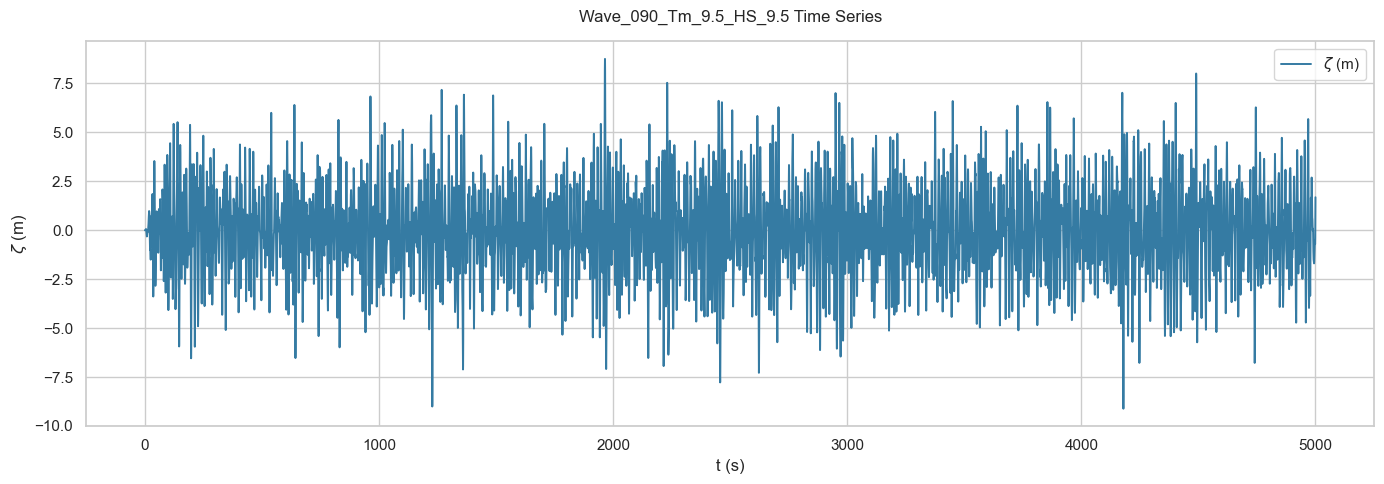

In [2]:
WAVE_CSV_PATH = Path("dataset_grid/Wave_090_Tm_9.5_HS_9.5.csv")

wave_df = pd.read_csv(WAVE_CSV_PATH)
wave_time_col = wave_df.columns[0]
wave_height_col = wave_df.columns[1]
wave_label_map = {col: format_column_label(col) for col in wave_df.columns}

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=wave_df,
    x=wave_time_col,
    y=wave_height_col,
    ax=ax,
    label=wave_label_map[wave_height_col],
    color=sns.color_palette("mako", n_colors=3)[1],
    linewidth=1.4,
)

ax.set_title("Wave_090_Tm_9.5_HS_9.5 Time Series", pad=14)
ax.set_xlabel(wave_label_map[wave_time_col])
ax.set_ylabel(wave_label_map[wave_height_col])
ax.legend(loc="upper right", frameon=True)

fig.tight_layout()
plt.show()


모델 로드 완료
사용 컬럼: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
입력 shape: (256, 6)
예측 shape: (256, 6)


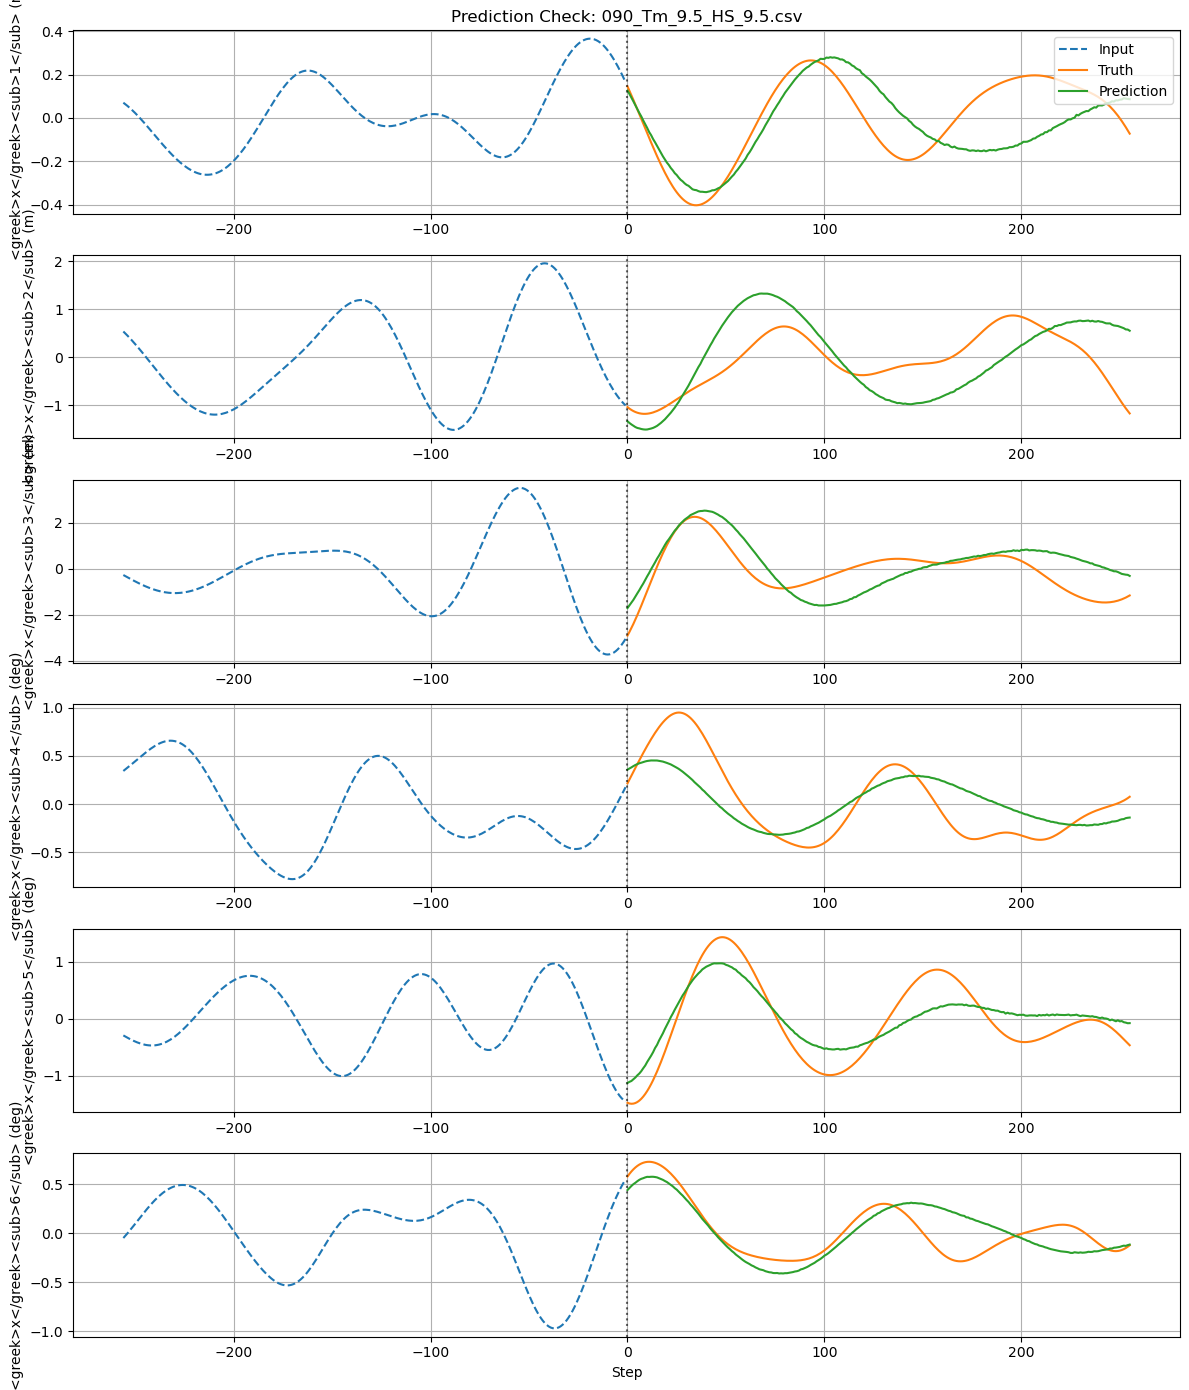

In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# 1. 모델 클래스 정의
# ==============================
class FlexibleTimeCNN(nn.Module):
    def __init__(
        self,
        in_dof=6,
        channels=64,
        kernel_sizes=None,
        use_bn=True,
        dropout=0.0,
    ):
        super().__init__()

        self.layers = nn.ModuleList()
        for i, ks in enumerate(kernel_sizes):
            padding = ks // 2
            in_ch = in_dof if i == 0 else channels

            conv = nn.Conv1d(
                in_channels=in_ch,
                out_channels=channels,
                kernel_size=ks,
                stride=1,
                padding=padding,
            )
            bn = nn.BatchNorm1d(channels) if use_bn else nn.Identity()
            self.layers.append(nn.Sequential(conv, bn, nn.ReLU()))

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        for block in self.layers:
            x = block(x)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        return x

class TimeCNNRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        cnn_channels=64,
        kernel_sizes=None,
        conv_use_bn=True,
        conv_dropout=0.0,
    ):
        super().__init__()
        self.out_dof = out_dof
        self.out_len = out_len

        self.cnn = FlexibleTimeCNN(
            in_dof=in_dof,
            channels=cnn_channels,
            kernel_sizes=kernel_sizes,
            use_bn=conv_use_bn,
            dropout=conv_dropout,
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(cnn_channels, 256),
            nn.ReLU(),
            nn.Linear(256, out_len * out_dof),
            nn.Sigmoid(),
        )

    def forward(self, src):
        x = self.cnn(src)
        x = x.permute(0, 2, 1)
        x = self.global_pool(x)
        x = self.fc(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

# ==============================
# 2. 모델 로드
# ==============================
MODEL_PATH = "models/timecnn_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
dof_cols = checkpoint["dof_cols"]
time_col = checkpoint["time_col"]
data_min = checkpoint["data_min"]
data_range = checkpoint["data_range"]

model = TimeCNNRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    cnn_channels=model_config["cnn_channels"],
    kernel_sizes=model_config["kernel_sizes"],
    conv_use_bn=model_config["conv_use_bn"],
    conv_dropout=model_config["conv_dropout"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("모델 로드 완료")
print("사용 컬럼:", dof_cols)

# ==============================
# 3. 예측 대상 데이터 읽기
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

# 예시: 시작 위치 지정
start_idx = 210

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("선택한 start_idx 기준으로 IN_LEN + OUT_LEN 길이가 데이터보다 깁니다.")

# 입력/정답 구간
x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

# 스케일링
x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

# 역스케일링
y_pred_raw = y_pred_scaled * data_range + data_min

print("입력 shape:", x_raw.shape)
print("예측 shape:", y_pred_raw.shape)

# ==============================
# 4. 결과 시각화
# ==============================
dof_names = dof_cols

fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=False)

t_input = np.arange(-IN_LEN, 0)
t_future = np.arange(OUT_LEN)

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", label="Input")
    ax.plot(t_future, y_true_raw[:, i], label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(dof_names[i])
    ax.grid(True)

axes[0].set_title(f"Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Step")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

# 2. ModernTCN

Using device: cuda:0
cuDNN enabled: False
모델 로드 완료
time_col: t (s)
dof_cols: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
model_type: ModernTCN
입력 shape: (256, 6)
예측 shape: (256, 6)


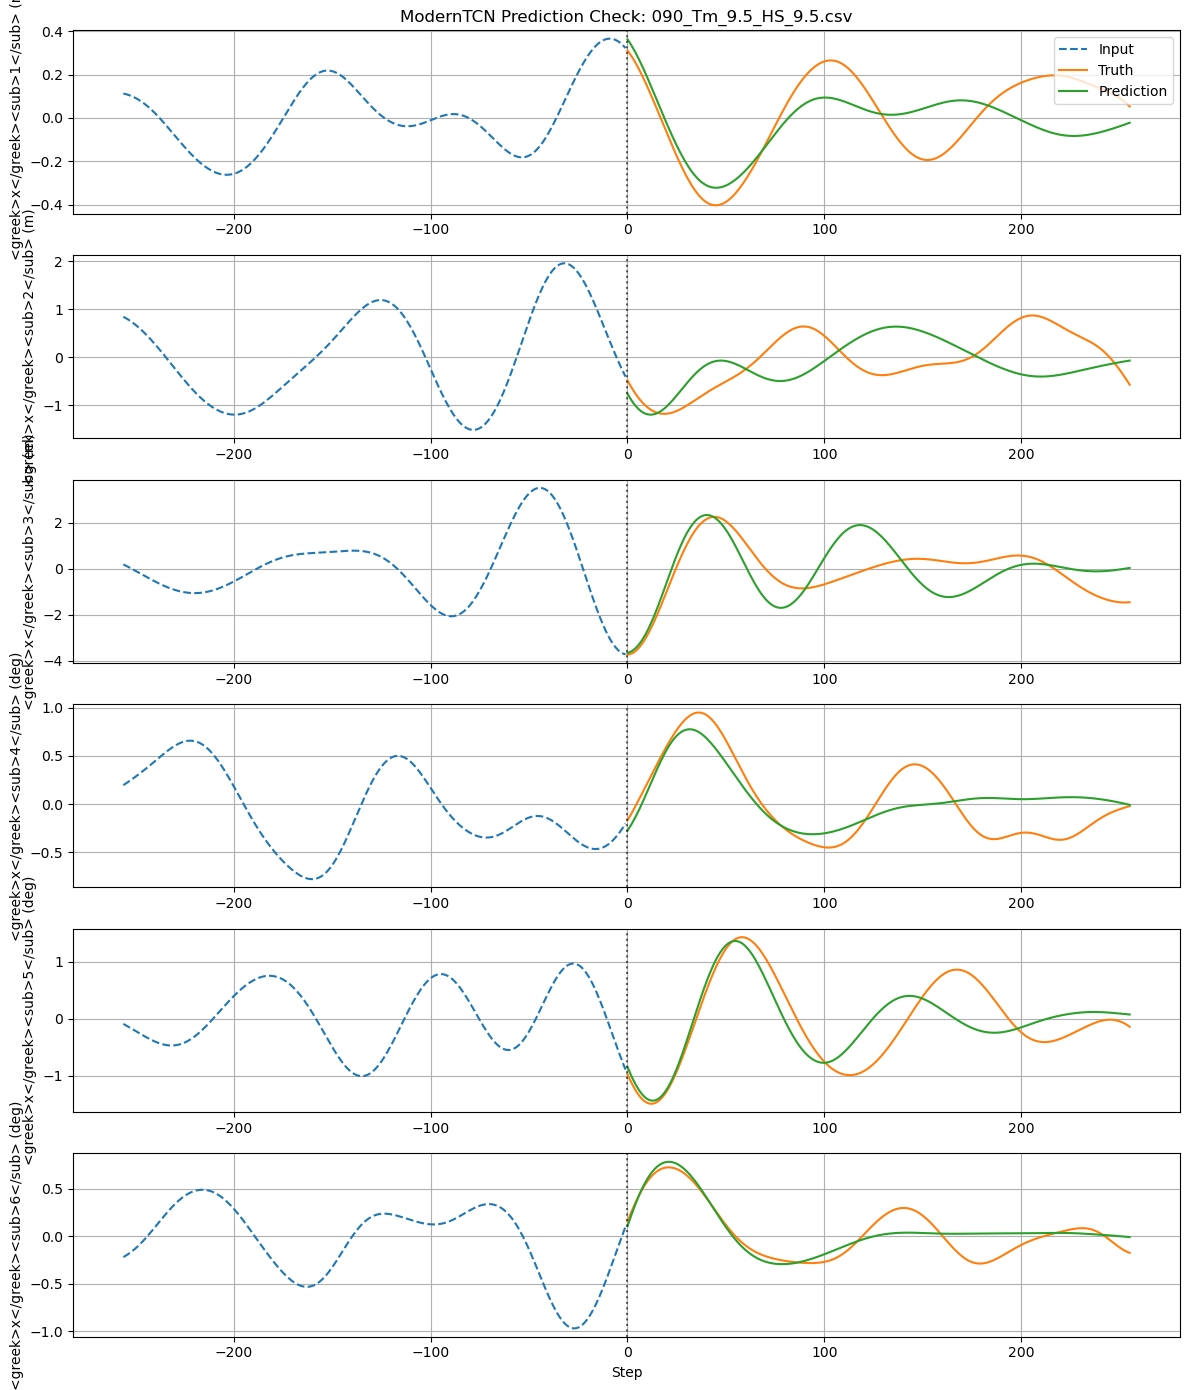

In [11]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Conda Auto 환경 라이브러리를 우선 사용해 CUDA/cuDNN 충돌을 줄인다.
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

# ==============================
# 1. ModernTCN 정의
# ==============================
class PermuteToChannelsFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

class PermuteToTimeFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

class ModernTCNBlock(nn.Module):
    def __init__(self, channels, kernel_size=31, expansion=2.0, dropout=0.1):
        super().__init__()

        hidden_dim = int(channels * expansion)
        padding = kernel_size // 2

        self.dwconv = nn.Conv1d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=channels,
            bias=True,
        )

        self.norm = ChannelLayerNorm(channels)

        self.pwffn = nn.Sequential(
            nn.Conv1d(channels, hidden_dim, kernel_size=1, bias=True),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, channels, kernel_size=1, bias=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwffn(x)
        x = x + residual
        return x

class ModernTCNBackbone(nn.Module):
    def __init__(
        self,
        in_dof=6,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
    ):
        super().__init__()

        stem_padding = stem_kernel_size // 2

        self.input_proj = nn.Sequential(
            PermuteToChannelsFirst(),
            nn.Conv1d(in_dof, channels, kernel_size=stem_kernel_size, padding=stem_padding, bias=True),
        )

        self.blocks = nn.ModuleList([
            ModernTCNBlock(
                channels=channels,
                kernel_size=kernel_size,
                expansion=expansion,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])

        self.out_permute = PermuteToTimeFirst()

    def forward(self, x):
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        x = self.out_permute(x)
        return x

class ModernTCNRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
        head_hidden_dim=256,
    ):
        super().__init__()

        self.out_len = out_len
        self.out_dof = out_dof

        self.backbone = ModernTCNBackbone(
            in_dof=in_dof,
            channels=channels,
            num_blocks=num_blocks,
            kernel_size=kernel_size,
            expansion=expansion,
            dropout=dropout,
            stem_kernel_size=stem_kernel_size,
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len * out_dof),
            nn.Sigmoid(),
        )

    def forward(self, src):
        x = self.backbone(src)
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

# ==============================
# 2. 체크포인트 로드
# ==============================
MODEL_PATH = "models_ModernTCN/moderntcn_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
time_col = checkpoint["time_col"]
dof_cols = checkpoint["dof_cols"]
data_min = checkpoint["data_min"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model = ModernTCNRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    channels=model_config["channels"],
    num_blocks=model_config["num_blocks"],
    kernel_size=model_config["kernel_size"],
    expansion=model_config["expansion"],
    dropout=model_config["dropout"],
    stem_kernel_size=model_config["stem_kernel_size"],
    head_hidden_dim=model_config["head_hidden_dim"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("모델 로드 완료")
print("time_col:", time_col)
print("dof_cols:", dof_cols)
print("model_type:", model_config["model_type"])

# ==============================
# 3. 예측 대상 CSV 읽기
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

# 예측 시작 인덱스
start_idx = 200

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("선택한 start_idx 기준으로 IN_LEN + OUT_LEN이 데이터 길이를 초과합니다.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

# min-max scaling
x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

# inverse scaling
y_pred_raw = y_pred_scaled * data_range + data_min

print("입력 shape:", x_raw.shape)
print("예측 shape:", y_pred_raw.shape)

# ==============================
# 4. 결과 시각화
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=False)

t_input = np.arange(-IN_LEN, 0)
t_future = np.arange(OUT_LEN)

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", label="Input")
    ax.plot(t_future, y_true_raw[:, i], label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(dof_cols[i])
    ax.grid(True)

axes[0].set_title(f"ModernTCN Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Step")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

# 3. CDCIHybrid

Using device: cuda:0
cuDNN enabled: False
모델 로드 완료
time_col: t (s)
dof_cols: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
channel_groups: [['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)'], ['<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']]
입력 shape: (256, 6)
예측 shape: (256, 6)


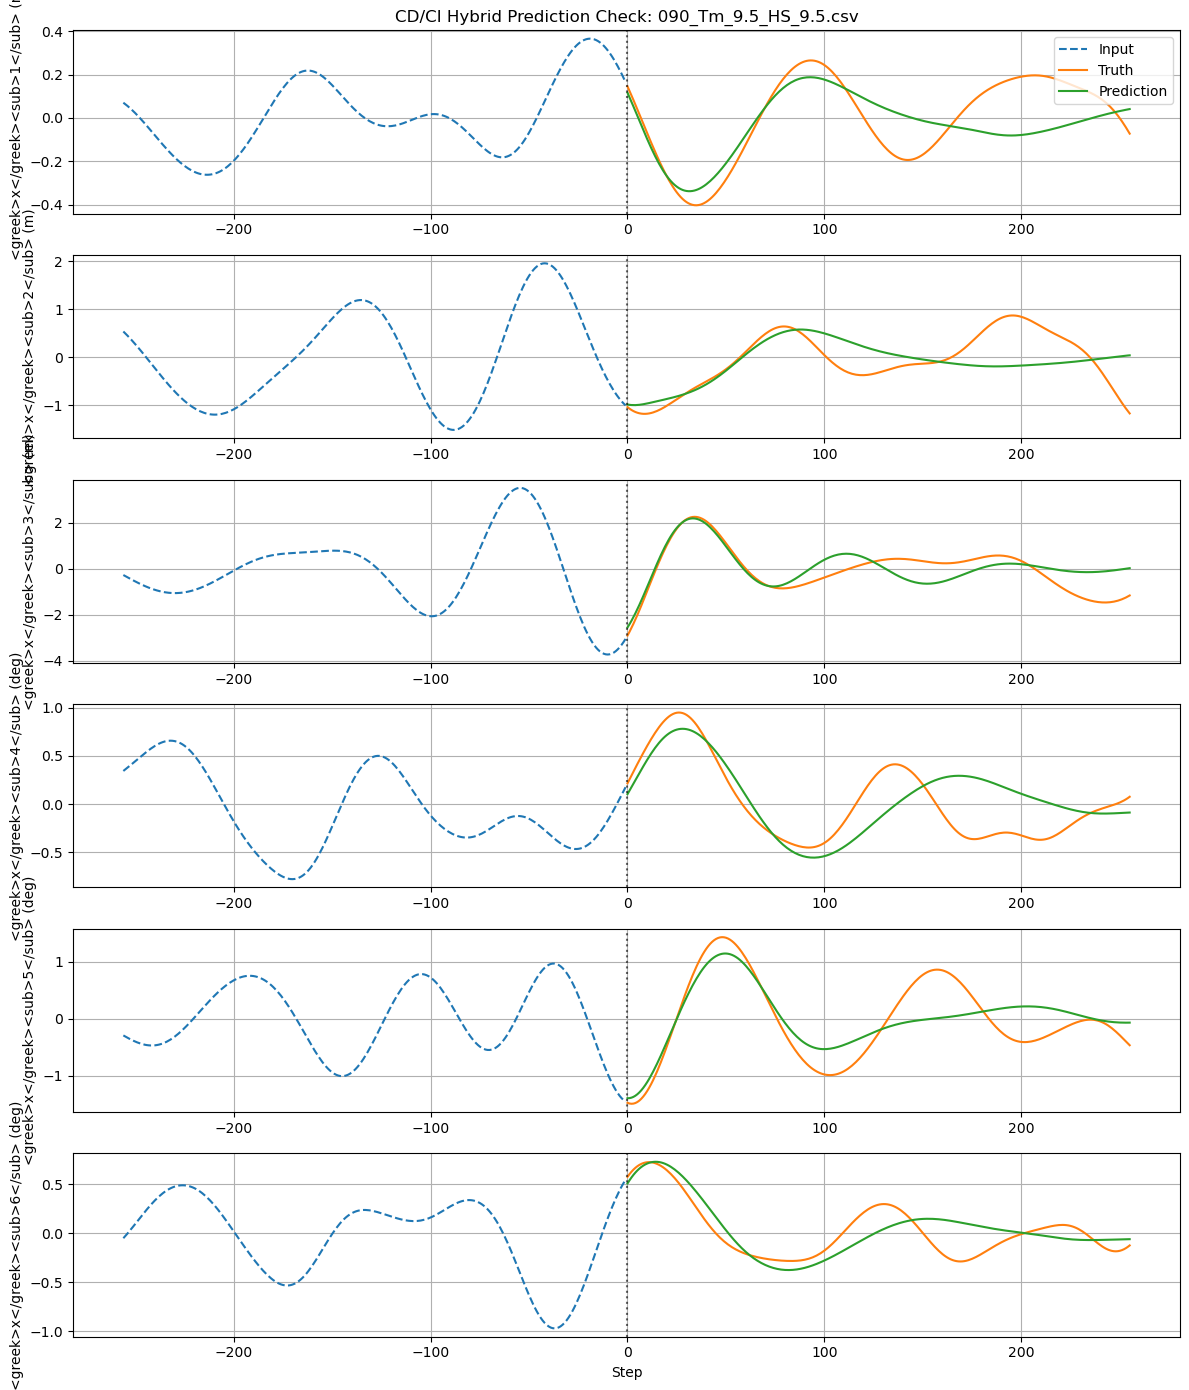

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Conda Auto 환경 라이브러리를 우선 사용해 CUDA/cuDNN 충돌을 줄인다.
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

# ==============================
# 1. 모델 정의
# ==============================
class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

class SharedClusterBlock(nn.Module):
    def __init__(self, channels, kernel_size=31, expansion=2.0, dropout=0.1):
        super().__init__()

        hidden_dim = int(channels * expansion)
        padding = kernel_size // 2

        self.dwconv = nn.Conv1d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=channels,
            bias=True,
        )
        self.norm = ChannelLayerNorm(channels)
        self.ffn = nn.Sequential(
            nn.Conv1d(channels, hidden_dim, kernel_size=1, bias=True),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, channels, kernel_size=1, bias=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.ffn(x)
        x = x + residual
        return x

class SharedClusterEncoder(nn.Module):
    def __init__(
        self,
        cluster_size=3,
        hidden_channels=96,
        num_blocks=5,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
    ):
        super().__init__()

        stem_padding = stem_kernel_size // 2

        self.input_proj = nn.Conv1d(
            in_channels=cluster_size,
            out_channels=hidden_channels,
            kernel_size=stem_kernel_size,
            padding=stem_padding,
            bias=True,
        )

        self.blocks = nn.ModuleList([
            SharedClusterBlock(
                channels=hidden_channels,
                kernel_size=kernel_size,
                expansion=expansion,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        x = x.transpose(1, 2)
        return x

class SharedClusterHead(nn.Module):
    def __init__(
        self,
        hidden_channels=96,
        out_len=256,
        cluster_size=3,
        head_hidden_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        self.out_len = out_len
        self.cluster_size = cluster_size
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len * cluster_size),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(-1, self.out_len, self.cluster_size)
        return x

class CDCIHybridRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        channel_groups=None,
        hidden_channels=96,
        num_blocks=5,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
        head_hidden_dim=256,
    ):
        super().__init__()

        if channel_groups is None:
            channel_groups = [[0, 1, 2], [3, 4, 5]]

        self.out_len = out_len
        self.out_dof = out_dof
        self.channel_groups = channel_groups

        group_sizes = [len(g) for g in channel_groups]
        self.cluster_size = group_sizes[0]

        self.shared_encoder = SharedClusterEncoder(
            cluster_size=self.cluster_size,
            hidden_channels=hidden_channels,
            num_blocks=num_blocks,
            kernel_size=kernel_size,
            expansion=expansion,
            dropout=dropout,
            stem_kernel_size=stem_kernel_size,
        )

        self.shared_head = SharedClusterHead(
            hidden_channels=hidden_channels,
            out_len=out_len,
            cluster_size=self.cluster_size,
            head_hidden_dim=head_hidden_dim,
            dropout=dropout,
        )

    def forward(self, src):
        batch_size = src.size(0)
        pred_full = src.new_zeros((batch_size, self.out_len, self.out_dof))

        for group in self.channel_groups:
            x_group = src[:, :, group]
            z_group = self.shared_encoder(x_group)
            y_group = self.shared_head(z_group)
            pred_full[:, :, group] = y_group

        return pred_full

# ==============================
# 2. 체크포인트 로드
# ==============================
MODEL_PATH = "models_CDCIHybrid/cdcihybrid_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
time_col = checkpoint["time_col"]
dof_cols = checkpoint["dof_cols"]
data_min = checkpoint["data_min"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model = CDCIHybridRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    channel_groups=model_config["channel_groups"],
    hidden_channels=model_config["hidden_channels"],
    num_blocks=model_config["num_blocks"],
    kernel_size=model_config["kernel_size"],
    expansion=model_config["expansion"],
    dropout=model_config["dropout"],
    stem_kernel_size=model_config["stem_kernel_size"],
    head_hidden_dim=model_config["head_hidden_dim"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("모델 로드 완료")
print("time_col:", time_col)
print("dof_cols:", dof_cols)
print("channel_groups:", model_config["channel_group_names"])

# ==============================
# 3. 예측 대상 CSV 읽기
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

start_idx = 210

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("선택한 start_idx 기준으로 IN_LEN + OUT_LEN이 데이터 길이를 초과합니다.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

y_pred_raw = y_pred_scaled * data_range + data_min

print("입력 shape:", x_raw.shape)
print("예측 shape:", y_pred_raw.shape)

# ==============================
# 4. 결과 시각화
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=False)

t_input = np.arange(-IN_LEN, 0)
t_future = np.arange(OUT_LEN)

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", label="Input")
    ax.plot(t_future, y_true_raw[:, i], label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(dof_cols[i])
    ax.grid(True)

axes[0].set_title(f"CD/CI Hybrid Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Step")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()